# Typing Speeds

How can you improve your typing speed?

The file `typing-speeds.csv` contains typing speed data from >168,000 people typing 15 sentences each. The data was collected via an online typing test published at a free typing speed assessment webpage.

In [27]:
# FOR GOOGLE COLAB ONLY.
# Uncomment and run the code below. A dialog will appear to upload files.
# Upload 'typing-speeds.csv'.

# from google.colab import files
# uploaded = files.upload()

In [28]:
import pandas as pd

df = pd.read_csv('typing-speeds.csv')
df

,PARTICIPANT_ID,AGE,HAS_TAKEN_TYPING_COURSE,COUNTRY,LAYOUT,NATIVE_LANGUAGE,FINGERS,KEYBOARD_TYPE,ERROR_RATE,AVG_WPM_15,ROR
0,3,30,0,US,qwerty,en,1-2,full,0.511945,61.9483,0.2288
1,5,27,0,MY,qwerty,en,7-8,laptop,0.871080,72.8871,0.3675
2,7,13,0,AU,qwerty,en,7-8,laptop,6.685633,24.1809,0.0667
3,23,21,0,IN,qwerty,en,3-4,full,2.130493,24.7112,0.0413
4,24,21,0,PH,qwerty,tl,7-8,laptop,1.893287,45.3364,0.2678
...,...,...,...,...,...,...,...,...,...,...,...
168589,517932,20,0,US,qwerty,en,9-10,laptop,8.731466,24.9125,0.1842
168590,517936,25,0,PL,qwerty,pl,9-10,laptop,0.000000,66.2946,0.0639
168591,517943,38,1,US,qwerty,en,9-10,laptop,0.147929,75.6713,0.2021
168592,517944,28,0,GB,qwerty,en,9-10,laptop,0.278552,91.7083,0.5133




| **Variable**             | **Description**                                                                 |
|--------------------------|---------------------------------------------------------------------------------|
| `PARTICIPANT_ID`         | Unique ID of the participant                                                   |
| `AGE`                    | Age of the participant                                                         |
| `HAS_TAKEN_TYPING_COURSE`| Whether the participant has taken a typing course (1 = Yes, 0 = No)            |
| `COUNTRY`                | Country of the participant                                                     |
| `LAYOUT`      		   | Keyboard layout used (QWERTY, AZERTY, or QWERTZ)                               |
| `NATIVE_LANGUAGE`        | Native language of the participant                                             |
| `FINGERS`                | Number of fingers used for typing (options: 1-2, 3-4, 5-6, 7-8, 9-10)          |
| `KEYBOARD_TYPE`          | Type of keyboard used (Full/desktop, laptop, small physical, or touch)         |
| `ERROR_RATE(%)`          | Uncorrected error rate (as a percentage)                                       |
| `AVG_WPM_15`             | Words per minute averaged over 15 typed sentences                              |
| `ROR`                    | Rollover ratio                                                                 |


### Project Ideas
- Remove unnecessary columns, such as PARTICIPANT_ID, to streamline the dataset.

- Rename columns (e.g `AVG_WPM_15` to `wpm`, `ROR` to `ror`, `HAS_TAKEN_TYPING_COURSE` to `course`) for brevity and clarity during analysis.

Finger Count Analysis
- Compare typing speeds across groups using different numbers of fingers, excluding the "10+" category for simplicity.

- Control for consistency by first filtering to similar `AGE`, `KEYBOARD_LAYOUT`, `NATIVE_LANGUAGE`, `KEYBOARD_TYPE`, and `HAS_TAKEN_TYPING_COURSE` values.

- Exclude participants with high error rates (ERROR_RATE > 3%) to focus on reliable data.

- Drop columns after filtering if they now only have a single value.

Rollover Ratio Analysis
- The Rollover Ratio (`ROR`) represents the proportion of keypresses where a new key is pressed before releasing the previous one.

- Compare typing speeds between participants with `ROR` ≤ 20% and those with `ROR` > 80%, keeping `AGE`, `KEYBOARD_TYPE`, `FINGERS`, and other variables constant.

Influence of Typing Course
- Compare typing speeds between participants with a typing course (`HAS_TAKEN_TYPING_COURSE` = 1) and without (`HAS_TAKEN_TYPING_COURSE` = 0), holding other variables such as `KEYBOARD_TYPE`, `AGE` range, and `FINGER_COUNT` constant.


In [29]:
df = df.drop(columns='PARTICIPANT_ID')
df.columns = df.columns.str.lower()
name_map = {
    'avg_wpm_15': 'wpm',
    'ror': 'rollover_ratio',
    'has_taken_typing_course': 'course'
}
df = df.rename(columns=name_map)
df

,age,course,country,layout,native_language,fingers,keyboard_type,error_rate,wpm,rollover_ratio
0,30,0,US,qwerty,en,1-2,full,0.511945,61.9483,0.2288
1,27,0,MY,qwerty,en,7-8,laptop,0.871080,72.8871,0.3675
2,13,0,AU,qwerty,en,7-8,laptop,6.685633,24.1809,0.0667
3,21,0,IN,qwerty,en,3-4,full,2.130493,24.7112,0.0413
4,21,0,PH,qwerty,tl,7-8,laptop,1.893287,45.3364,0.2678
...,...,...,...,...,...,...,...,...,...,...
168589,20,0,US,qwerty,en,9-10,laptop,8.731466,24.9125,0.1842
168590,25,0,PL,qwerty,pl,9-10,laptop,0.000000,66.2946,0.0639
168591,38,1,US,qwerty,en,9-10,laptop,0.147929,75.6713,0.2021
168592,28,0,GB,qwerty,en,9-10,laptop,0.278552,91.7083,0.5133


,country,fingers,error_rate,wpm,rollover_ratio
0,US,1-2,0.511945,61.9483,0.2288
1,MY,7-8,0.871080,72.8871,0.3675
3,IN,3-4,2.130493,24.7112,0.0413
4,PH,7-8,1.893287,45.3364,0.2678
5,IN,7-8,0.747384,54.6831,0.4434
...,...,...,...,...,...
168588,CA,7-8,2.686567,51.6231,0.4465
168590,PL,9-10,0.000000,66.2946,0.0639
168591,US,9-10,0.147929,75.6713,0.2021
168592,GB,9-10,0.278552,91.7083,0.5133


,fingers,error_rate,wpm,rollover_ratio,wpm_normalized
0,1-2,0.970086,41.086000,0.172530,0.000000
1,3-4,1.008086,41.659045,0.163240,0.034032
2,5-6,0.944694,46.348648,0.209606,0.312543
3,7-8,0.868934,50.606678,0.259212,0.565422
4,9-10,0.752451,57.924182,0.317827,1.000000


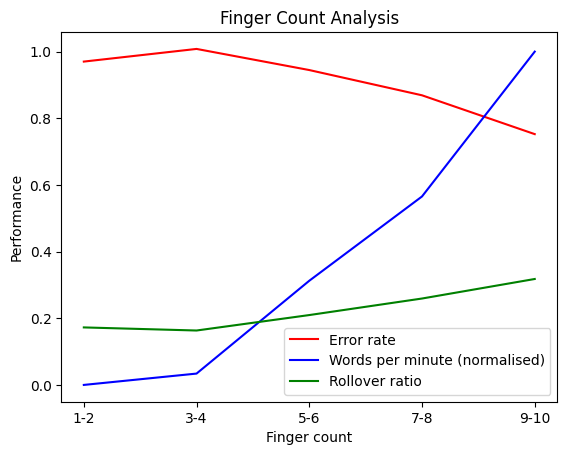

In [30]:
finger_count_analysis = df.drop(columns=['age', 'layout', 'native_language', 'keyboard_type', 'course']).query('error_rate < 3')
finger_count_analysis = finger_count_analysis[finger_count_analysis['fingers'] != '10+']
fingers = finger_count_analysis.groupby('fingers')[['error_rate', 'wpm', 'rollover_ratio']].mean().reset_index()
fingers['wpm_normalized'] = (fingers['wpm'] - fingers['wpm'].min()) / (fingers['wpm'].max() - fingers['wpm'].min())

display(finger_count_analysis)
display(fingers)

import matplotlib.pyplot as plt

plt.plot(fingers['fingers'], fingers['error_rate'], label='Error rate', color='red', linestyle='-')
plt.plot(fingers['fingers'], fingers['wpm_normalized'], label='Words per minute (normalised)', color='blue', linestyle='-')
plt.plot(fingers['fingers'], fingers['rollover_ratio'], label='Rollover ratio', color='green', linestyle='-')
plt.title('Finger Count Analysis')
plt.xlabel('Finger count')
plt.ylabel('Performance')
plt.legend()
plt.show()

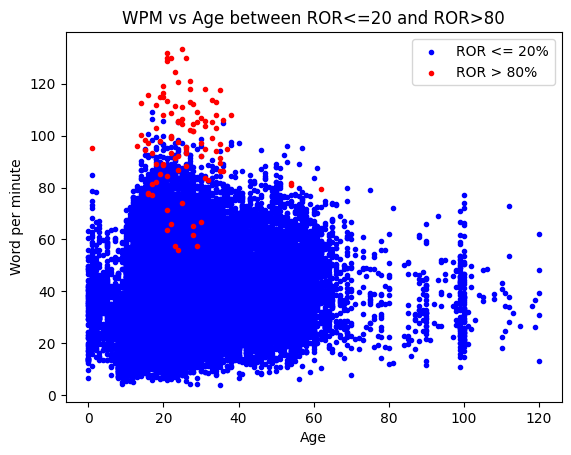

,layout,ror_20_wpm,ror_80_wpm
0,azerty,31.532023,NaN
1,dvorak,34.485966,92.286600
2,qwerty,37.465243,98.272779
3,qwertz,34.136852,NaN


,native_language,ror_20_wpm,ror_80_wpm
29,de,43.781267,115.699000
33,en,37.847004,98.040973


,keyboard_type,ror_20_wpm,ror_80_wpm
0,full,38.313605,98.823892
1,laptop,36.875438,97.820671
2,on-screen,30.040435,NaN
3,small,35.527135,NaN


,course,ror_20_wpm,ror_80_wpm
0,0,36.906749,98.160088
1,1,38.698614,98.251893


In [38]:
ror_20 = df.query('rollover_ratio <= 0.2').rename(columns={'wpm': 'ror_20_wpm'})
ror_80 = df.query('rollover_ratio > 0.8').rename(columns={'wpm': 'ror_80_wpm'})

import matplotlib.pyplot as plt

fig, ax = plt.subplots()
ax.scatter(ror_20['age'], ror_20['ror_20_wpm'], color='blue', marker='.', label='ROR <= 20%')
ax.scatter(ror_80['age'], ror_80['ror_80_wpm'], color='red', marker='.', label='ROR > 80%')
ax.set_title('WPM vs Age between ROR<=20 and ROR>80')
ax.set_xlabel('Age')
ax.set_ylabel('Word per minute')
ax.legend()
plt.show()

ror_20_layout = ror_20.groupby('layout')['ror_20_wpm'].mean().reset_index()
ror_80_layout = ror_80.groupby('layout')['ror_80_wpm'].mean().reset_index()
layout = pd.merge(ror_20_layout, ror_80_layout, on='layout', how='outer')
display(layout)

ror_20_native_language = ror_20.groupby('native_language')['ror_20_wpm'].mean().reset_index()
ror_80_native_language = ror_80.groupby('native_language')['ror_80_wpm'].mean().reset_index()
native_language = pd.merge(ror_20_native_language, ror_80_native_language, on='native_language', how='outer').dropna()
display(native_language)

ror_20_keyboard_type = ror_20.groupby('keyboard_type')['ror_20_wpm'].mean().reset_index()
ror_80_keyboard_type = ror_80.groupby('keyboard_type')['ror_80_wpm'].mean().reset_index()
keyboard_type = pd.merge(ror_20_keyboard_type, ror_80_keyboard_type, on='keyboard_type', how='outer')
display(keyboard_type)

ror_20_course = ror_20.groupby('course')['ror_20_wpm'].mean().reset_index()
ror_80_course = ror_80.groupby('course')['ror_80_wpm'].mean().reset_index()
course = pd.merge(ror_20_course, ror_80_course, on='course', how='outer')
display(course)

In [40]:
course = df.groupby('course')[['error_rate', 'wpm', 'rollover_ratio']].mean().reset_index()
course

,course,error_rate,wpm,rollover_ratio
0,0,1.231374,49.008085,0.238936
1,1,1.021142,54.349929,0.288239
